In [1]:
import numpy as np
import polars as pl
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from working_data import clean_cols, clean_non_minute_rows, alt_label_df as label_df, normalize_by_window, split_df
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from model_builder_trans import combined_loss
from scipy.signal import savgol_filter



2024-10-29 11:41:07.336339: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-29 11:41:07.372109: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-29 11:41:08.089551: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2024-10-29 11:41:09.100428: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-10-29 11:41:09.123585: 

In [2]:
NORMALIZING_WINDOW_SIZE = 60*24
LABELING_WINDOW_SIZE = 20
POSITIVE_SLOPE = 0.3
LABEL_CUR_CANDLE_MULTIPLIER = 0
LABEL_MEAN_MULTIPLIER = 6
BATCH_SIZE = 32
NUM_TOKENS = 128
LOOKBACK_WINDOW = NUM_TOKENS + 1
D_MODEL = 128
FF_DIM = 256
NUM_HEADS = D_MODEL//16

In [3]:
source_csv = "data/GBPUSD/minutes.csv"
working_path = "working"

In [4]:
# df = pd.read_csv(source_csv)
# df = clean_non_minute_rows(df)
# df = clean_cols(df)
# break_point = len(df) - len(df)//2
# # cols = ['open', 'high', 'low', 'close']
# # signal = np.array(df[cols])
# # signal = np.apply_along_axis(lambda x: savgol_filter(x, window_length=5, polyorder=4), axis=0, arr=signal)
# # df[cols] = signal
# df = df[break_point:]
# df = normalize_by_window(
#     df, 
#     window_size=NORMALIZING_WINDOW_SIZE, 
#     normalizing_cols=[
#         'open',
#         'high',
#         'low',
#         'close',
#     ])
# print("labeling")
# df = label_df(df, window_size=LABELING_WINDOW_SIZE, mean_multiplier=LABEL_MEAN_MULTIPLIER, cur_candle_multiplier=LABEL_CUR_CANDLE_MULTIPLIER)
# print(df['target'].value_counts())
# split_df(
#     df=df, 
#     dump_path=working_path, 
#     cols=[
#         'open',
#         'high',
#         'low',
#         'close',
#         'open_normalized',
#         'high_normalized',
#         'low_normalized',
#         'close_normalized',
#         'target'
#     ])

In [5]:
def prepare_data(file_path, num_tokens, window_size=1440, batch_size=32, smote=False, shuffle=False, cols=['open', 'high', 'low', 'close']):
    scaler = MinMaxScaler()
    stand_scaler = StandardScaler()
    emd_range = window_size
    # Load CSV lazily with Polars
    collect_cols = cols + ['target']
    df_lazy = pl.scan_csv(file_path).select(collect_cols)
    
    # Collect the dataframe and determine total number of rows
    df_collected = df_lazy.collect()
    total_rows = df_collected.shape[0]
    if smote:
        df_collected = df_collected.with_columns(pl.arange(0, total_rows).alias("index"))
        indices_target_1 = df_collected.filter(
            (pl.col("target") == 1) & (pl.col("index") >= emd_range)
        ).select("index").to_series().to_list()

        # Get indices where target is 0 and >= num_tokens
        indices_target_0 = df_collected.filter(
            (pl.col("target") == 0) & (pl.col("index") >= emd_range)
        ).select("index").to_series().to_list()

        df_collected = df_collected.drop('index')
    
    while True:  # Loop to reshuffle and restart at each epoch
        # Create an array of indices to use for shuffling
        indices = list(range(emd_range, total_rows))
        if smote:
            indices_target_1_complete = []
            while len(indices_target_1_complete) < len(indices_target_0):
                indices_target_1_complete += indices_target_1

            indices_target_1_complete = indices_target_1_complete[:len(indices_target_0)]

            indices = indices_target_0 + indices_target_1_complete

        # Shuffle indices if required
        if shuffle:
            np.random.shuffle(indices)

        input_list = []
        target_list = []

        for idx in indices:
            #create imfs
            signal = np.array(df_collected[cols][idx - emd_range + 1:idx + 1])
            
            # signal = scaler.fit_transform(signal)

            # Fetch the previous `num_prev + 1` rows for the input based on the current index
            input_rows = signal[-num_tokens:]
            target_value = df_collected[idx, -1]  # Get 'target' for the target

            # Append the input rows to the input list
            input_list.append(input_rows)
            target_list.append(target_value)

            # Yield once we have enough for a batch
            if len(input_list) == batch_size:
                # Convert lists to NumPy arrays
                input_array = np.array(input_list)
                target_array = np.array(target_list)

                # Convert NumPy arrays to TensorFlow tensors
                input_tensor = tf.convert_to_tensor(input_array, dtype=tf.float32)
                target_tensor = tf.convert_to_tensor(target_array, dtype=tf.int32)

                yield input_tensor, target_tensor

                # Reset lists for the next batch

                input_list.clear()
                target_list.clear()

        break

In [6]:
def create_dataset_generator(file_path, batch_size, num_tokens, window_size=LOOKBACK_WINDOW, shuffle=False, repeat=False, smote=False, cols=['open', 'high', 'low', 'close']):
    dataset = tf.data.Dataset.from_generator(
        lambda: prepare_data(file_path, window_size=window_size, batch_size=batch_size, num_tokens=num_tokens, shuffle=shuffle, smote=smote, cols=cols),
        output_signature=(
            tf.TensorSpec(shape=(None, num_tokens, len(cols)), dtype=tf.float32),
            tf.TensorSpec(shape=(None,), dtype=tf.int32)
        )
    )
    if repeat:
        dataset = dataset.repeat()
    return dataset 

In [7]:
def get_total_rows(file_path, num_tokens, smote=False):
    # Count the total number of rows in the CSV file
    df_lazy = pl.scan_csv(file_path)
    df_collected = df_lazy.collect()
    total_rows = df_collected.shape[0]
    if not smote:
        return total_rows
    df_collected = df_collected.with_columns(pl.arange(0, total_rows).alias("index"))
    indices_target_0 = df_collected.filter(
            (pl.col("target") == 0) & (pl.col("index") >= num_tokens)
    )
    return len(indices_target_0) * 2

In [8]:
train_path = 'small_data/train/EURUSD.csv'
val_path = 'small_data/val/EURUSD.csv'
test_path = 'small_data/test/EURUSD.csv'

cols = [
    'open_normalized',
    'high_normalized',
    'low_normalized',
    'close_normalized'
]

train_dataset = create_dataset_generator(train_path, batch_size=BATCH_SIZE, num_tokens=NUM_TOKENS, repeat=True, shuffle=True, smote=True, cols=cols)
val_dataset = create_dataset_generator(val_path, batch_size=BATCH_SIZE, num_tokens=NUM_TOKENS, repeat=True, cols=cols)
test_dataset = create_dataset_generator(test_path, batch_size=BATCH_SIZE, num_tokens=NUM_TOKENS, cols=cols)

train_steps = get_total_rows(train_path, num_tokens=LOOKBACK_WINDOW, smote=True)//BATCH_SIZE
val_steps = get_total_rows(val_path, num_tokens=LOOKBACK_WINDOW)//BATCH_SIZE
test_steps = get_total_rows(test_path, num_tokens=LOOKBACK_WINDOW)//BATCH_SIZE

In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, concatenate, LayerNormalization, Dropout, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.layers import MultiHeadAttention, Add, Embedding

input_length = NUM_TOKENS 

class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, maxlen, d_model):
        super(PositionalEncoding, self).__init__()
        self.pos_encoding = self.positional_encoding(maxlen, d_model)

    def positional_encoding(self, maxlen, d_model):
        positions = np.arange(maxlen)[:, np.newaxis]
        angles = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (angles // 2)) / np.float32(d_model))
        angle_rads = positions * angle_rates

        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]


class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential(
            [Dense(ff_dim, activation="relu"), Dense(embed_dim)]
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)
    


In [10]:
auc =  tf.keras.metrics.AUC()
auc.reset_state()
prec = tf.keras.metrics.Precision()
prec.reset_state()

In [11]:
input_shape = (NUM_TOKENS, 4)

input_layer = Input(shape=input_shape)
x = Conv1D(filters=D_MODEL//2, kernel_size=3, activation='relu', padding="same")(input_layer)
x = Conv1D(filters=D_MODEL, kernel_size=3, activation='relu', padding="same")(x)
x = MaxPooling1D(pool_size=2, padding="same")(x)
x = Dropout(0.1)(x)
x = PositionalEncoding(x.shape[1], d_model=D_MODEL)(x)
x = TransformerBlock(D_MODEL, NUM_HEADS, FF_DIM)(x, training=True)
x = TransformerBlock(D_MODEL, NUM_HEADS, FF_DIM)(x, training=True)
x = TransformerBlock(D_MODEL, NUM_HEADS, FF_DIM)(x, training=True)
x = TransformerBlock(D_MODEL, NUM_HEADS, FF_DIM)(x, training=True)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs=input_layer, outputs=outputs)

model.load_weights("working/best_cnn_trans_layer_3.keras", skip_mismatch=True)

learning_rate = 1e-3  # Adjust this value as needed
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)


# Compile the model
model.compile(
    optimizer=optimizer, 
    loss=combined_loss, 
    metrics=['accuracy',auc, prec])

model.summary()


/home/dima/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:591: UserWarning: A total of 8 objects could not be loaded. Example error message for object <EinsumDense name=key, built=True>:

Layer 'key' expected 2 variables, but received 0 variables during loading. Expected: ['kernel', 'bias']

List of objects that could not be loaded:
[<EinsumDense name=key, built=True>, <EinsumDense name=attention_output, built=True>, <EinsumDense name=query, built=True>, <EinsumDense name=value, built=True>, <Dense name=dense_6, built=True>, <Dense name=dense_7, built=True>, <LayerNormalization name=layer_normalization_6, built=True>, <LayerNormalization name=layer_normalization_7, built=True>]
  warnings.warn(msg)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 64)        │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 64, 128)        │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 64, 128)        │       593,920 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 64, 128)        │       593,920 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 64, 128)        │       593,920 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 64, 128)        │       593,920 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,401,345 (9.16 MB)

 Trainable params: 2,401,345 (9.16 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stopping = EarlyStopping(monitor='val_precision_1', 
                               patience=10, # Stops if there's no improvement in precision for 5 epochs
                               mode='max', 
                               verbose=1)

model_checkpoint = ModelCheckpoint('best_cnn_trans_model.keras', 
                                   monitor='val_precision_1', 
                                   save_best_only=True, 
                                   mode='max', 
                                   verbose=1)

# model.load_weights('best_cnn_trans_model.keras')

# Train the model using the train and validation datasets
history = model.fit(
    train_dataset,
    epochs=50,
    steps_per_epoch = train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps,
    callbacks=[early_stopping, model_checkpoint]
)


# Load the best model after training
model.load_weights('best_cnn_trans_model.keras')


Epoch 1/50


I0000 00:00:1730194882.588178   16416 service.cc:145] XLA service 0x7f3e20001770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1730194882.588268   16416 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2024-10-29 11:41:22.823468: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-10-29 11:41:23.669640: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1730194889.593658   16563 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_163', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1730194890.817774   16561 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_163', 60 bytes spill stores, 60 bytes spill loads



    1/18333 ━━━━━━━━━━━━━━━━━━━━ 157:53:28 31s/step - accuracy: 0.5312 - auc: 0.5333 - loss: 5.5935 - precision_1: 0.5312

I0000 00:00:1730194904.935165   16416 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_19', 500 bytes spill stores, 500 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_17', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1730194904.950309   16416 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 5376/18333 ━━━━━━━━━━━━━━━━━━━━ 6:24 30ms/step - accuracy: 0.6835 - auc: 0.7449 - loss: 0.9944 - precision_1: 0.6669

In [ ]:
predictions = model.predict(test_dataset)

# Convert probabilities to binary class (0 or 1) using a threshold of 0.5
predicted_class = (predictions > 0.5).astype(int)

2102/2102 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step


2024-10-26 13:57:36.135919: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
y_true = []

for input_tensor, target_tensor in test_dataset:
    y_true.extend(target_tensor.numpy()) 

2024-10-26 13:58:19.850327: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Confusion Matrix:
 [[46557 12796]
 [ 3705  4206]]


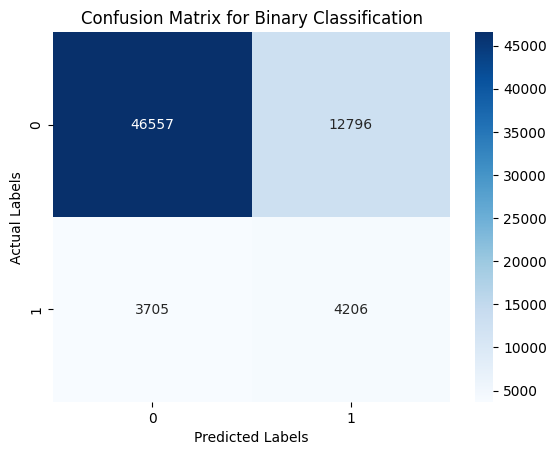

In [ ]:
conf_matrix = confusion_matrix(y_true, predicted_class)

print("Confusion Matrix:\n", conf_matrix)

# Optionally: Visualize the confusion matrix using a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix for Binary Classification')
plt.show()

In [ ]:
model.evaluate(test_dataset)

2102/2102 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - accuracy: 0.7640 - auc: 0.7755 - loss: 0.8515 - precision_1: 0.2697


2024-10-26 13:59:10.611177: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2024-10-26 13:59:10.611233: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2024-10-26 13:59:10.611251: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 2234962397263165800
2024-10-26 13:59:10.611270: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 10211193333264481304
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, trac

[0.8583120107650757,
 0.7546830177307129,
 0.7688869833946228,
 0.24738265573978424]

In [ ]:
model.save_weights('cnn_trans_layer_4.weights.h5')